# 10_02.K-Means Clustering



## 1.기본 package 설정

In [ ]:
## 1.기본
import numpy as np  # numpy 패키지 가져오기
import matplotlib.pyplot as plt # 시각화 패키지 가져오기
import seaborn as sns # 시각화

## 2.데이터 가져오기
import pandas as pd # csv -> dataframe으로 전환

## 데이터 전처리
from sklearn.preprocessing import StandardScaler # 연속변수의 표준화

## 모델구축
from sklearn.cluster import KMeans

## 2.데이터 불러오기

### 2.1 구글 드라이브와 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2.2 데이터 프레임으로 저장
- 원본데이터(csv)를 dataframe 형태로 가져오기(pandas)

In [ ]:
utilities_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Utilities.csv')
utilities_df.head()

,Company,Fixed_charge,RoR,Cost,Load_factor,Demand_growth,Sales,Nuclear,Fuel_Cost
0,Arizona,1.06,9.2,151,54.4,1.6,9077,0.0,0.628
1,Boston,0.89,10.3,202,57.9,2.2,5088,25.3,1.555
2,Central,1.43,15.4,113,53.0,3.4,9212,0.0,1.058
3,Commonwealth,1.02,11.2,168,56.0,0.3,6423,34.3,0.700
4,NY,1.49,8.8,192,51.2,1.0,3300,15.6,2.044


### 2.3 자료구조 살펴보기

In [ ]:
utilities_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        22 non-null     object 
 1   Fixed_charge   22 non-null     float64
 2   RoR            22 non-null     float64
 3   Cost           22 non-null     int64  
 4   Load_factor    22 non-null     float64
 5   Demand_growth  22 non-null     float64
 6   Sales          22 non-null     int64  
 7   Nuclear        22 non-null     float64
 8   Fuel_Cost      22 non-null     float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.7+ KB


In [ ]:
utilities_df.columns

Index(['Company', 'Fixed_charge', 'RoR', 'Cost', 'Load_factor',
       'Demand_growth', 'Sales', 'Nuclear', 'Fuel_Cost'],
      dtype='object')

## 3.데이터 전처리

### 3.1 필요없는 변수 제거

In [ ]:
utilities_df = utilities_df.drop(['Company'], axis=1)
utilities_df

,Fixed_charge,RoR,Cost,Load_factor,Demand_growth,Sales,Nuclear,Fuel_Cost
0,1.06,9.2,151,54.4,1.6,9077,0.0,0.628
1,0.89,10.3,202,57.9,2.2,5088,25.3,1.555
2,1.43,15.4,113,53.0,3.4,9212,0.0,1.058
3,1.02,11.2,168,56.0,0.3,6423,34.3,0.700
4,1.49,8.8,192,51.2,1.0,3300,15.6,2.044
5,1.32,13.5,111,60.0,-2.2,11127,22.5,1.241
6,1.22,12.2,175,67.6,2.2,7642,0.0,1.652
7,1.10,9.2,245,57.0,3.3,13082,0.0,0.309
8,1.34,13.0,168,60.4,7.2,8406,0.0,0.862
9,1.12,12.4,197,53.0,2.7,6455,39.2,0.623


### 3.2 EDA 데이터 탐색

In [ ]:
# 수치형 변수
utilities_df.describe()

,Fixed_charge,RoR,Cost,Load_factor,Demand_growth,Sales,Nuclear,Fuel_Cost
count,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.00000,22.000000
mean,1.114091,10.736364,168.181818,56.977273,3.240909,8914.045455,12.00000,1.102727
std,0.184511,2.244049,41.191349,4.461148,3.118250,3549.984031,16.79192,0.556098
min,0.750000,6.400000,96.000000,49.800000,-2.200000,3300.000000,0.00000,0.309000
25%,1.042500,9.200000,148.500000,53.775000,1.450000,6458.250000,0.00000,0.630000
50%,1.110000,11.050000,170.500000,56.350000,3.000000,8024.000000,0.00000,0.960000
75%,1.190000,12.350000,195.750000,60.300000,5.350000,10128.250000,24.60000,1.516250
max,1.490000,15.400000,252.000000,67.600000,9.200000,17441.000000,50.20000,2.116000


### 3.3 그래프 그리기

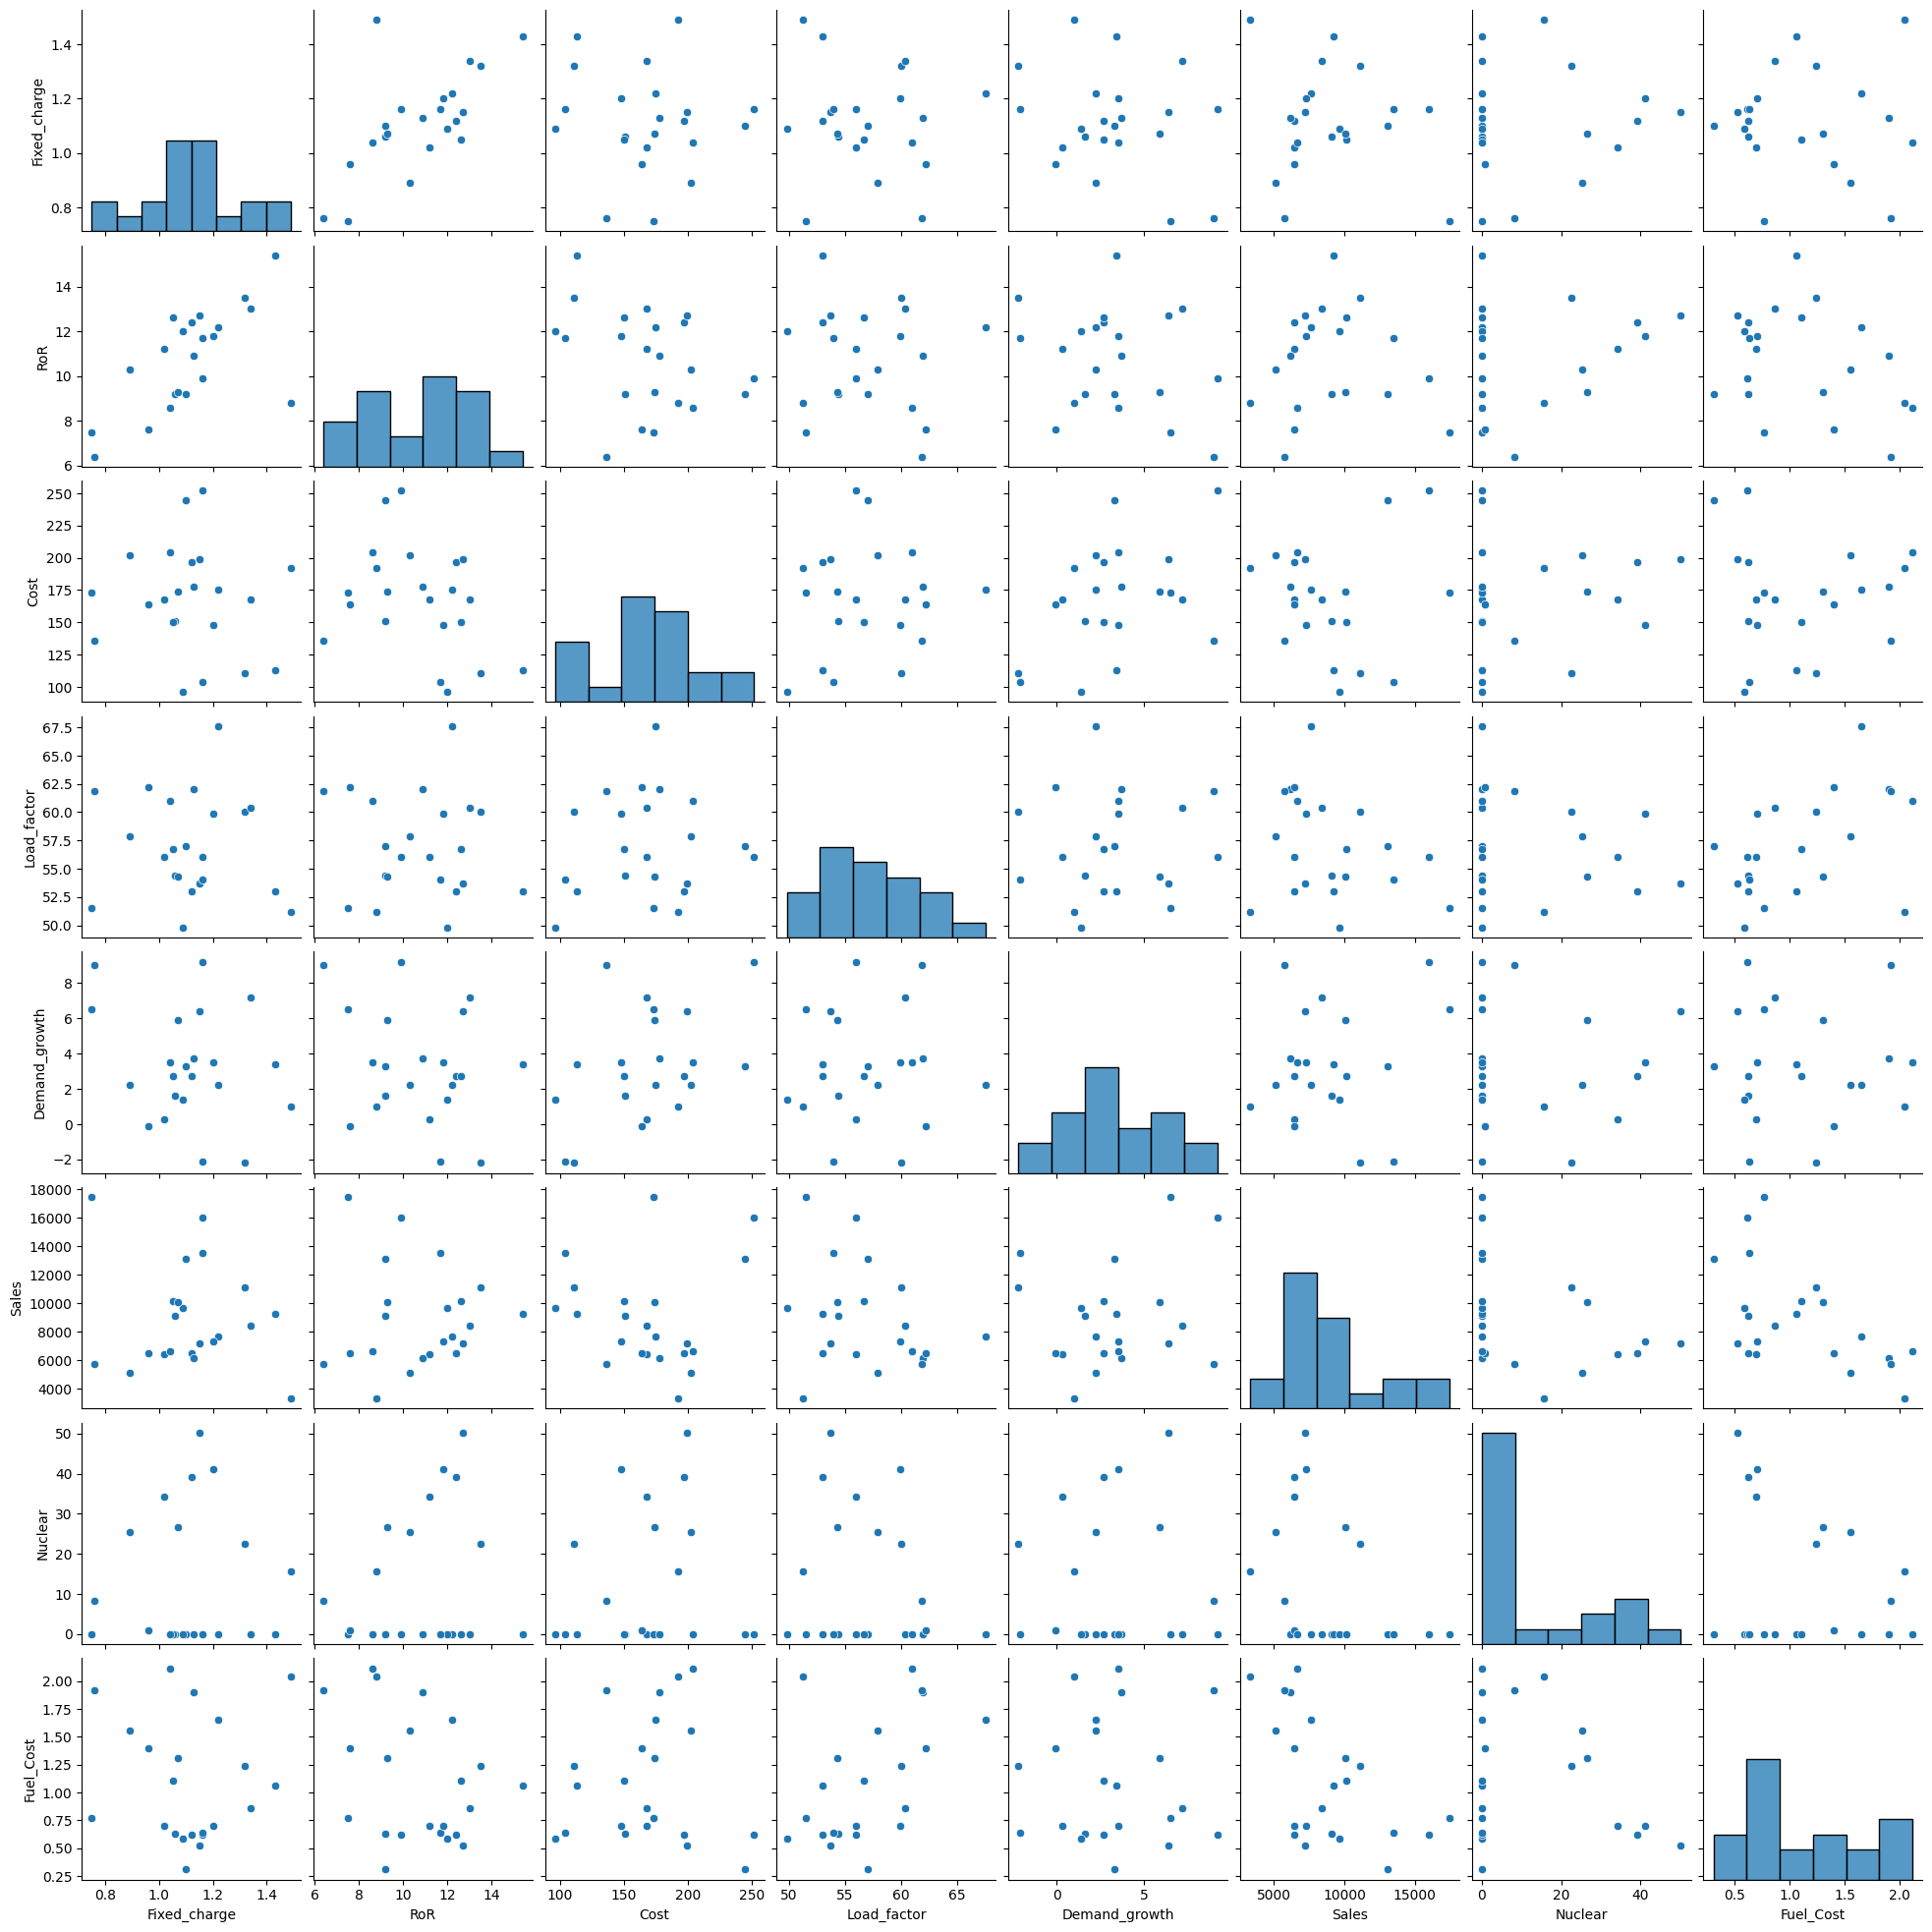

In [ ]:
# 수치형 변수
g = sns.pairplot(utilities_df)

### 3.3 표준화

In [ ]:
utilities_df = pd.DataFrame(StandardScaler().fit_transform(utilities_df),
                            columns = utilities_df.columns)
utilities_df.head()

,Fixed_charge,RoR,Cost,Load_factor,Demand_growth,Sales,Nuclear,Fuel_Cost
0,-0.300057,-0.700750,-0.426938,-0.591310,-0.538611,0.046983,-0.731447,-0.873765
1,-1.243092,-0.199030,0.840322,0.211704,-0.341667,-1.103127,0.810687,0.832436
2,1.752432,2.127130,-1.371171,-0.912516,0.052220,0.085906,-0.731447,-0.082323
3,-0.521947,0.211469,-0.004518,-0.224218,-0.965322,-0.718219,1.359271,-0.741244
4,2.085268,-0.883194,0.591840,-1.325495,-0.735555,-1.618644,0.219434,1.732470


## 4.군집화

### 4.1.엘보우 차트(Elbow Method)


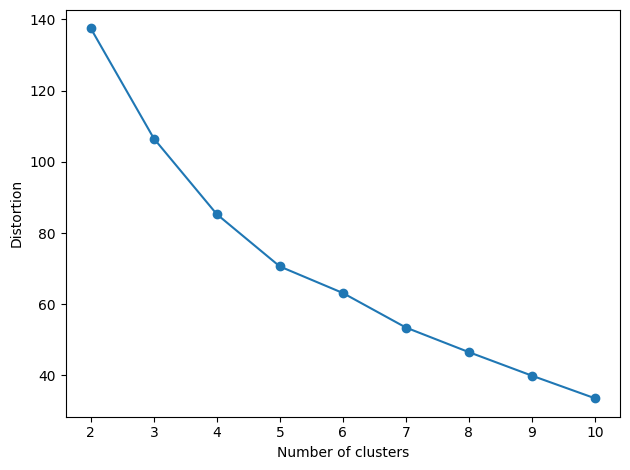

In [ ]:
distortions = []

for i in range(2, 11):
    km = KMeans(n_clusters=i,
                init='k-means++',
                n_init=10,
                max_iter=300,
                random_state=0)
    km.fit(utilities_df)
    distortions.append(km.inertia_)

plt.plot(range(2, 11), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.tight_layout()
plt.show()

### 4.2 군집화

In [ ]:
km = KMeans(n_clusters = 4,
            init='k-means++',
            n_init=10,
            max_iter=300,
            random_state=1)
# km.fit(utilities_df)
km = km.fit_predict(utilities_df)

### 4.3 silhouette 그래프

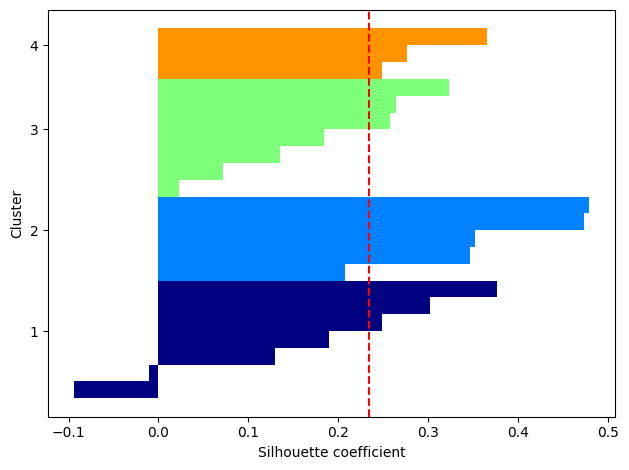

In [ ]:
from matplotlib import cm
from sklearn.metrics import silhouette_samples

cluster_labels = np.unique(km)
n_clusters = cluster_labels.shape[0]
silhouette_vals = silhouette_samples(utilities_df, km, metric='euclidean')
y_ax_lower, y_ax_upper = 0, 0
yticks = []
for i, c in enumerate(cluster_labels):
    c_silhouette_vals = silhouette_vals[km == c]
    c_silhouette_vals.sort()
    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / n_clusters)
    plt.barh(range(y_ax_lower, y_ax_upper), c_silhouette_vals, height=1.0,
             edgecolor='none', color=color)

    yticks.append((y_ax_lower + y_ax_upper) / 2.)
    y_ax_lower += len(c_silhouette_vals)

silhouette_avg = np.mean(silhouette_vals)
plt.axvline(silhouette_avg, color="red", linestyle="--")

plt.yticks(yticks, cluster_labels + 1)
plt.ylabel('Cluster')
plt.xlabel('Silhouette coefficient')

plt.tight_layout()
plt.show()

## 5.Cluster 특징

### 5.1 데이터 결합

In [ ]:
cluster_df = pd.DataFrame(km,
                          columns = ["cluster"])
cluster_df["cluster"] = cluster_df["cluster"].replace([0,1,2,3], ["cluster1","cluster2","cluster3","cluster4"])
cluster_df

,cluster
0,cluster3
1,cluster1
2,cluster3
3,cluster2
4,cluster1
5,cluster3
6,cluster1
7,cluster4
8,cluster3
9,cluster2


In [ ]:
cluster_df = pd.concat([utilities_df, cluster_df], axis=1, ignore_index=False)
cluster_df.head()

,Fixed_charge,RoR,Cost,Load_factor,Demand_growth,Sales,Nuclear,Fuel_Cost,cluster
0,-0.300057,-0.700750,-0.426938,-0.591310,-0.538611,0.046983,-0.731447,-0.873765,cluster3
1,-1.243092,-0.199030,0.840322,0.211704,-0.341667,-1.103127,0.810687,0.832436,cluster1
2,1.752432,2.127130,-1.371171,-0.912516,0.052220,0.085906,-0.731447,-0.082323,cluster3
3,-0.521947,0.211469,-0.004518,-0.224218,-0.965322,-0.718219,1.359271,-0.741244,cluster2
4,2.085268,-0.883194,0.591840,-1.325495,-0.735555,-1.618644,0.219434,1.732470,cluster1


### 5.2 cluster 분석

In [ ]:
cluster_df.groupby('cluster').mean()

,Fixed_charge,RoR,Cost,Load_factor,Demand_growth,Sales,Nuclear,Fuel_Cost
cluster,,,,,,,,
cluster1,-0.244584,-0.674687,0.261713,0.818061,-0.055630,-0.880708,-0.295191,1.279166
cluster2,-0.011599,0.339180,0.224086,-0.366466,0.170386,-0.411331,1.601868,-0.609460
cluster3,0.516184,0.797896,-1.009097,-0.345490,-0.501098,0.360140,-0.535523,-0.420198
cluster4,-0.614402,-0.852787,1.370418,-0.491890,1.015056,1.900210,-0.731447,-0.988493


### 5.3 cluster별 시각화

In [ ]:
cluster_long_df = pd.melt(cluster_df,
                          id_vars='cluster',
                          value_vars=['Fixed_charge', 'RoR', 'Cost', 'Load_factor', 'Demand_growth', 'Sales',
                                      'Nuclear', 'Fuel_Cost'])
cluster_long_df

,cluster,variable,value
0,cluster3,Fixed_charge,-0.300057
1,cluster1,Fixed_charge,-1.243092
2,cluster3,Fixed_charge,1.752432
3,cluster2,Fixed_charge,-0.521947
4,cluster1,Fixed_charge,2.085268
...,...,...,...
171,cluster3,Fuel_Cost,0.009705
172,cluster3,Fuel_Cost,-0.859040
173,cluster2,Fuel_Cost,-0.737563
174,cluster1,Fuel_Cost,1.864991


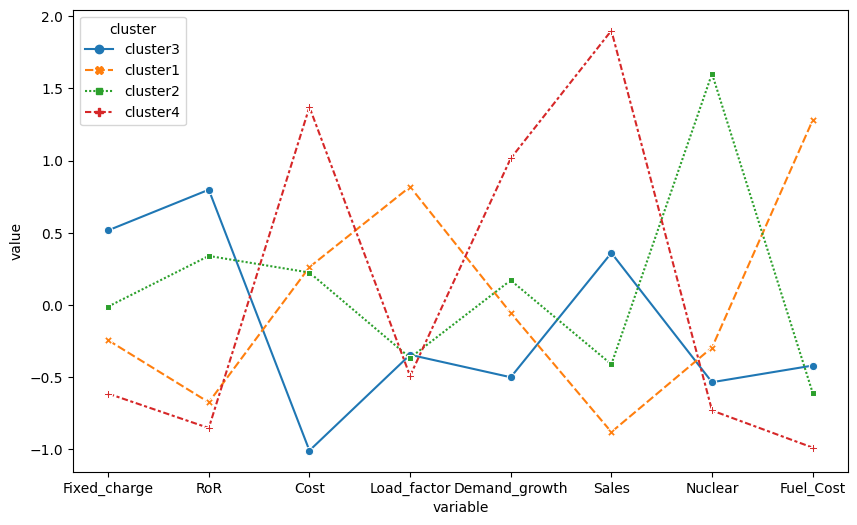

In [ ]:
fig = plt.figure(figsize=(10, 6))
sns.lineplot(data = cluster_long_df,
             x = 'variable',
             y = 'value',
             hue = 'cluster',
             style = 'cluster',
             err_style = None,
             markers = True)
plt.show()

### 5.4 그래프 그리기

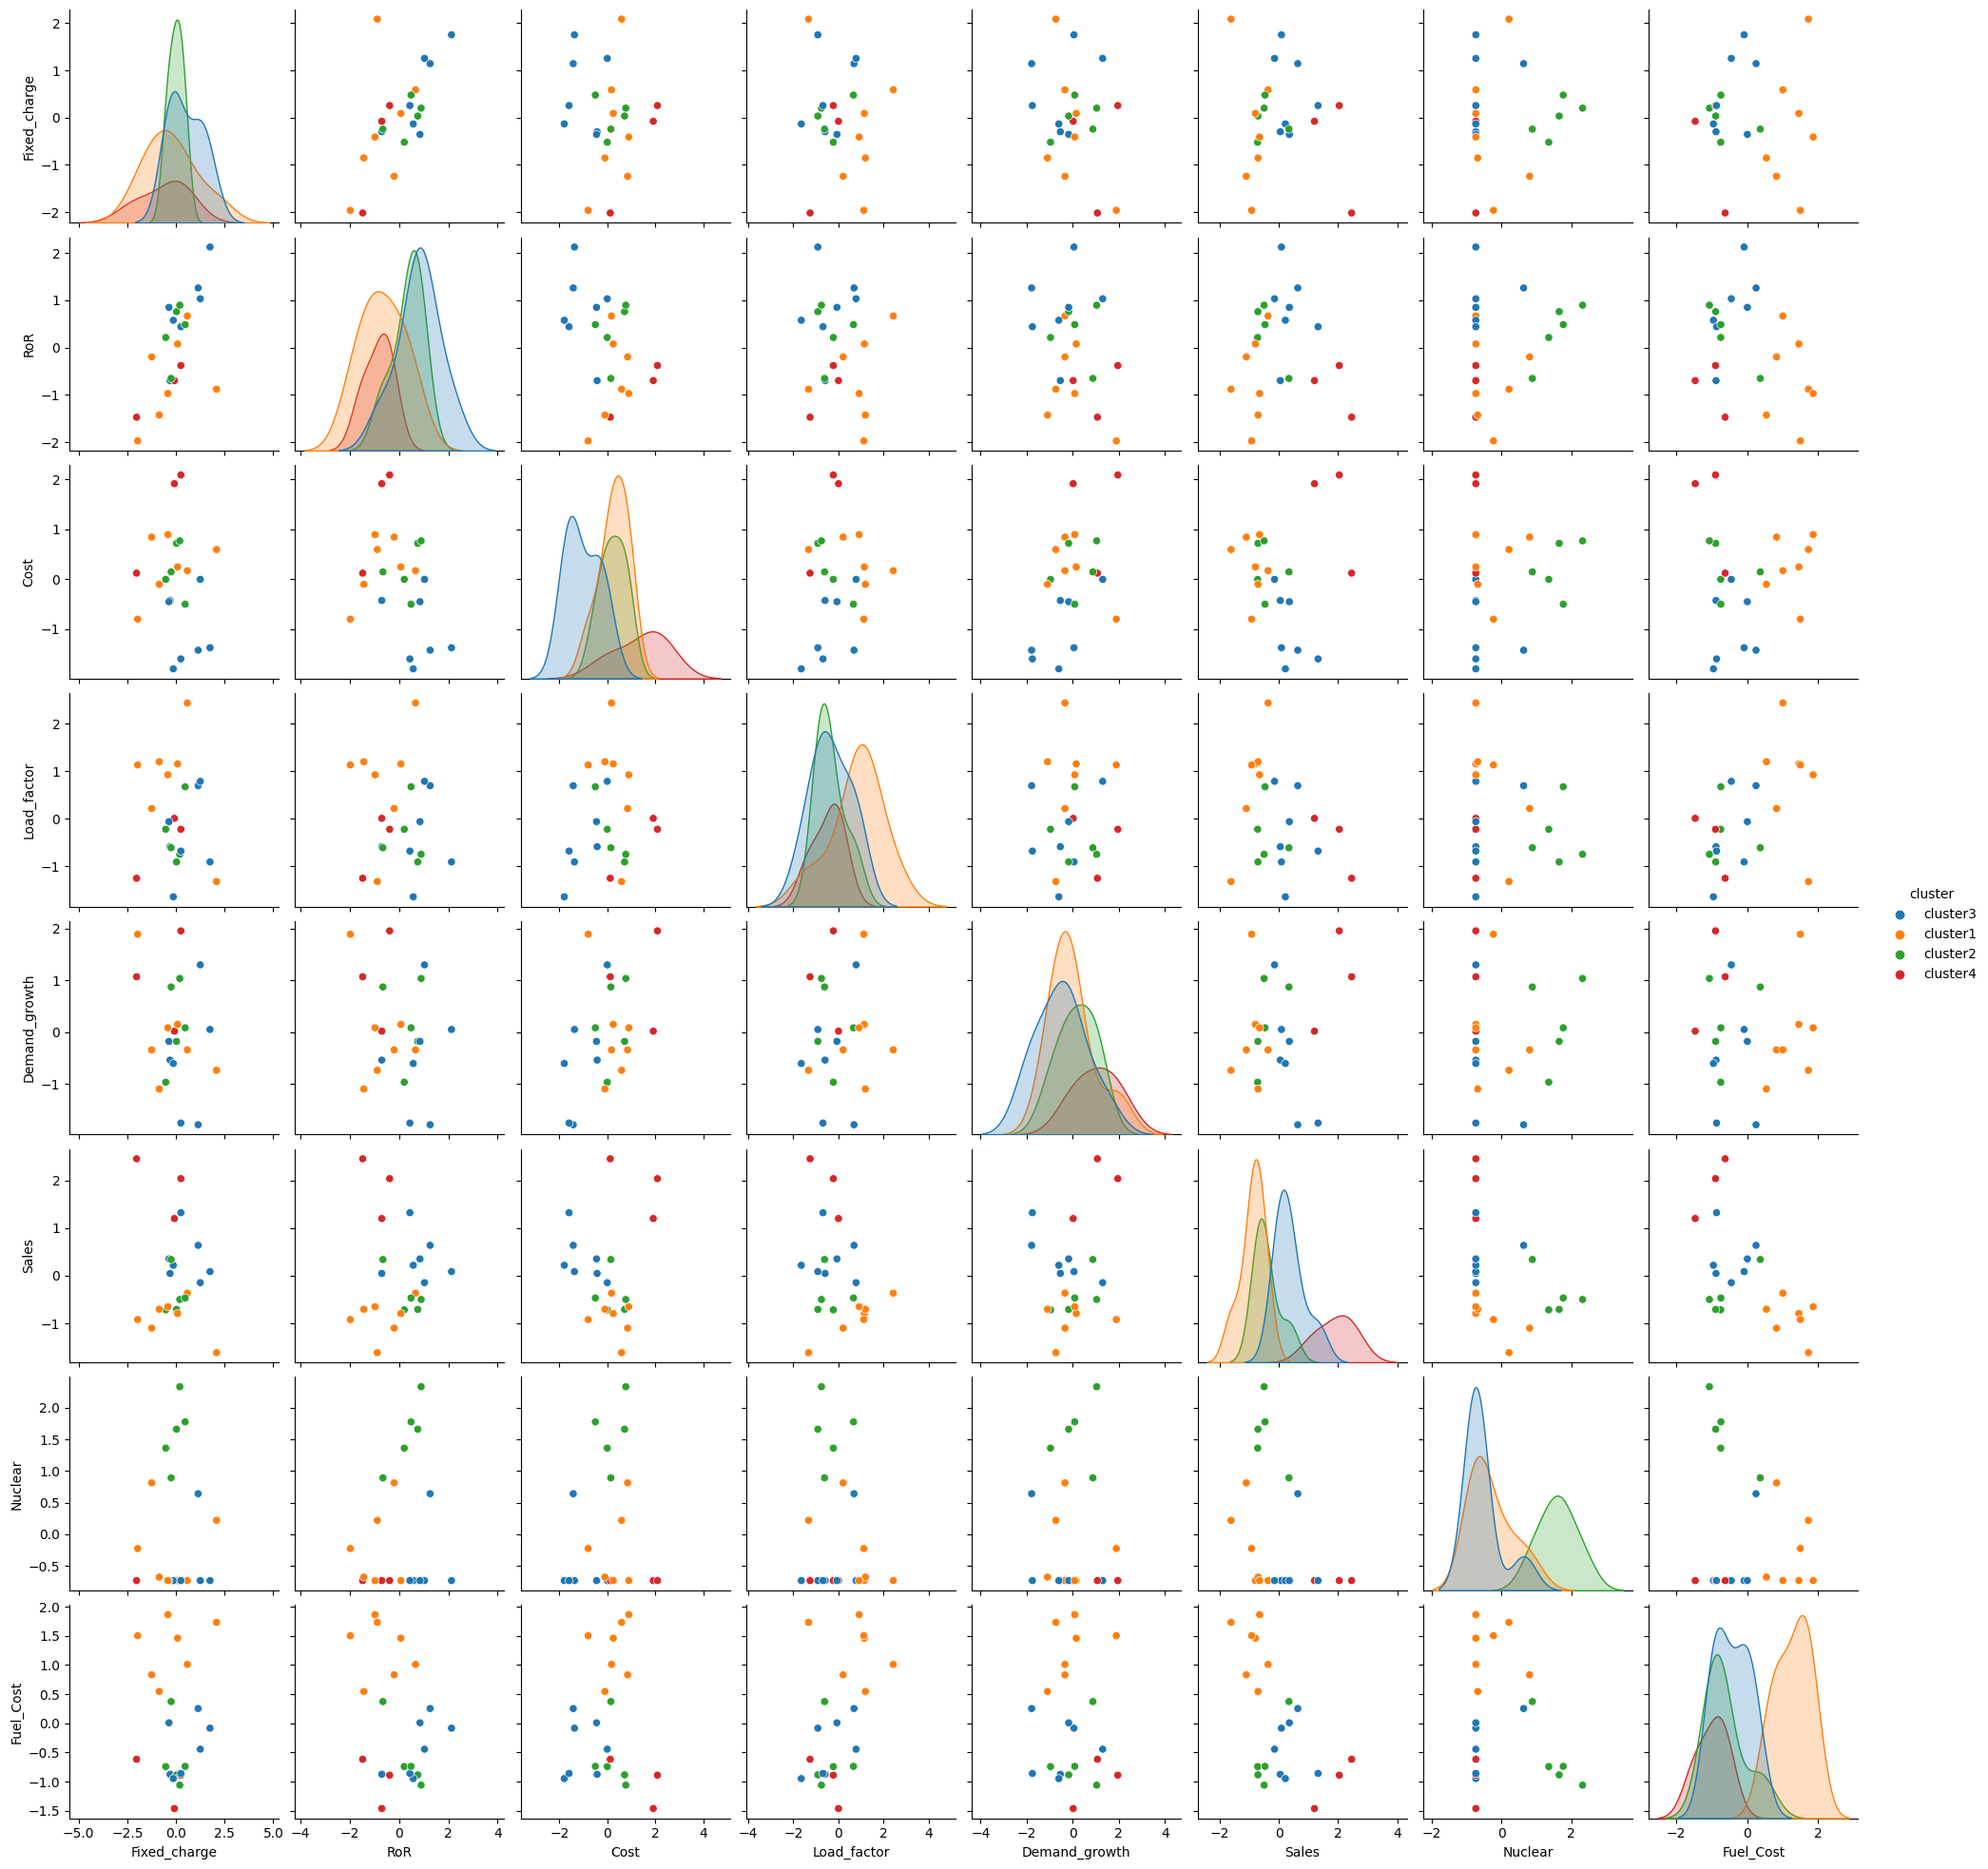

In [ ]:
g = sns.pairplot(cluster_df,
                 hue="cluster")